In [24]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_state_city
import matplotlib.pyplot as plt

In [25]:
# Параметри

n = 3               # кількість кубітів (довжина секретного рядка s)
s = '101'           # таємний рядок s

In [26]:
# Функція для оракула BV

def bv_oracle(qc, s):
    """Додає оракул U_f для BV до схеми qc"""
    for i, bit in enumerate(reversed(s)):
        if bit == '1':
            qc.cx(i, n)   # контрольний кубіт впливає на другий (target) кубіт
    return qc

In [27]:
# Квантова схема statevector

qc_sv = QuantumCircuit(n+1)       # n кубітів + 1 target
qc_sv.x(n)                        # останній кубіт |1> (target)
qc_sv.h(range(n+1))               # Hadamard на всіх кубітах

qc_sv = bv_oracle(qc_sv, s)       # виклик оракула
qc_sv.h(range(n))                 # Hadamard на перших n кубітах

# Отримуємо statevector
state = Statevector.from_instruction(qc_sv)
print("Statevector:\n", state)

# Візуалізація statevector
plot_state_city(state)
plt.show()

Statevector:
 Statevector([ 1.22527931e-34+0.j, -9.52420783e-18+0.j, -2.07756904e-51+0.j,
              6.49514367e-34+0.j,  6.73463194e-18+0.j,  7.07106781e-01+0.j,
              8.93190087e-35+0.j,  1.66988925e-17+0.j, -1.22527931e-34+0.j,
              9.52420783e-18+0.j,  2.07756904e-51+0.j, -6.49514367e-34+0.j,
             -6.73463194e-18+0.j, -7.07106781e-01+0.j, -8.93190087e-35+0.j,
             -1.66988925e-17+0.j],
            dims=(2, 2, 2, 2))


In [28]:
# Квантова схема QASM для вимірювання

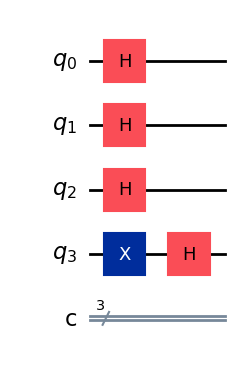

In [29]:
# Ініціалізація кубітів та класичних бітів

# n кубітів для входу + 1 кубіт target
# n класичних бітів для вимірювання перших n кубітів

qc = QuantumCircuit(n+1, n)

# Підготовка target кубіту у стан |1> та створення суперпозиції

qc.x(n)             # останній кубіт (target) у стан |1>
qc.h(range(n+1))    # Hadamard на всіх кубітах → суперпозиція всіх входів
qc.draw('mpl')

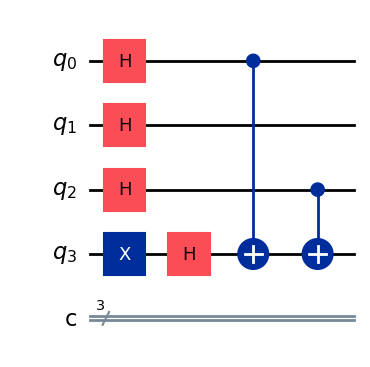

In [30]:
# Виклик оракула Бернштейна–Вазірані

qc = bv_oracle(qc, s)   # застосування U_f для секретного рядка s
qc.draw('mpl')

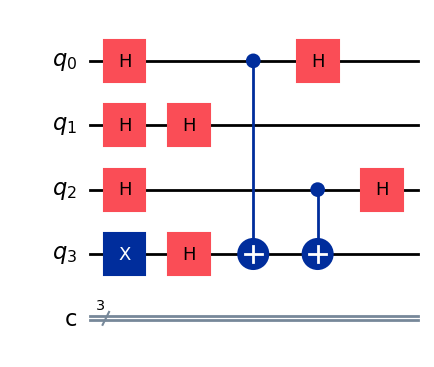

In [31]:
# Інтерференція для знаходження секретного рядка

qc.h(range(n))       # Hadamard на перших n кубітах
qc.draw('mpl')

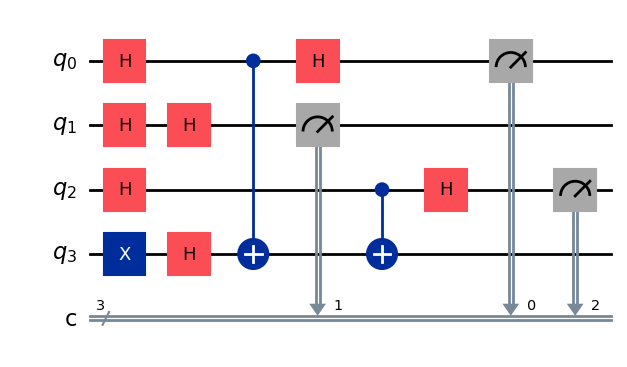

In [32]:
# Вимірювання кубітів

qc.measure(range(n), range(n))   # вимірюємо перші n кубітів і зберігаємо у класичні біти
qc.draw('mpl')

In [33]:
# Симуляція з вимірюванням
backend_qasm = AerSimulator()
compiled_qasm = transpile(qc, backend_qasm)
job = backend_qasm.run(compiled_qasm, shots=1)
counts = job.result().get_counts()
print("Counts:", counts)

# Результат: секретний рядок s
secret_found = list(counts.keys())[0]
print(f"Знайдений секретний рядок s: {secret_found}")

Counts: {'101': 1}
Знайдений секретний рядок s: 101
